## 1. Sự bào mòn của biên lợi nhuân gộp theo kịch bản khuyến mãi

C:\Users\Doan\AppData\Local\Temp\ipykernel_11116\3936403319.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


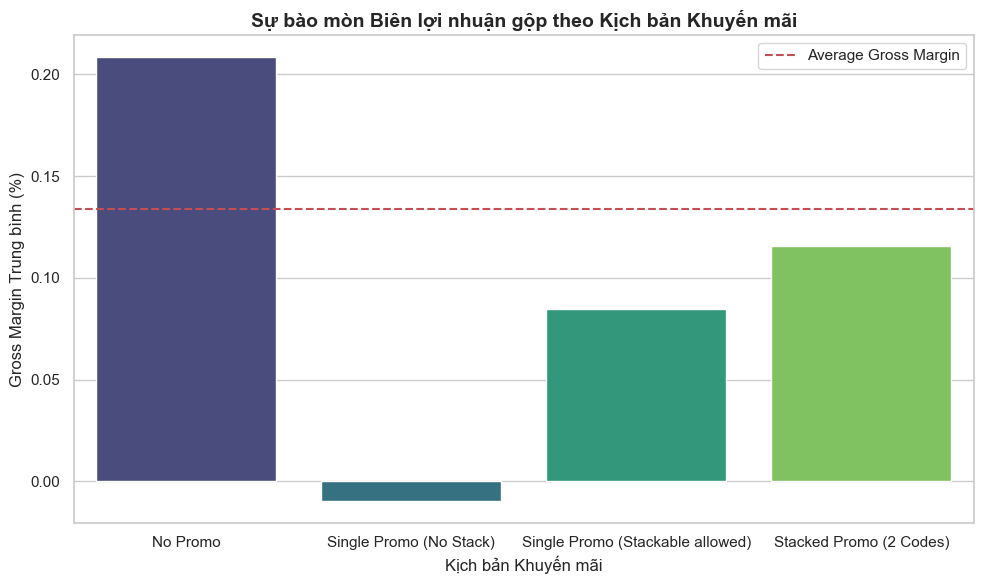

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dữ liệu (Giả sử các file CSV ở cùng thư mục)
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')
promotions = pd.read_csv('promotions.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
returns = pd.read_csv('returns.csv')
reviews = pd.read_csv('reviews.csv')
inventory = pd.read_csv('inventory.csv')
web_traffic = pd.read_csv('web_traffic.csv')

# Chuyển đổi các cột ngày tháng
orders['order_date'] = pd.to_datetime(orders['order_date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Xử lý dữ liệu (Giả sử các biến orders, order_items... đã được load)
df_promo = order_items.merge(products[['product_id', 'price', 'cogs', 'category']], on='product_id', how='left')
df_promo = df_promo.merge(promotions[['promo_id', 'stackable_flag']], on='promo_id', how='left')
df_promo['stackable_flag'] = df_promo['stackable_flag'].fillna(-1) 

df_promo['gross_margin'] = (df_promo['unit_price'] - df_promo['cogs']) / df_promo['unit_price']

def categorize_promo(flag, promo2):
    if pd.isna(promo2) and flag == -1: return 'No Promo'
    elif pd.notna(promo2): return 'Stacked Promo (2 Codes)'
    elif flag == 1: return 'Single Promo (Stackable allowed)'
    else: return 'Single Promo (No Stack)'

df_promo['promo_scenario'] = df_promo.apply(lambda x: categorize_promo(x['stackable_flag'], x['promo_id_2']), axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=df_promo, x='promo_scenario', y='gross_margin', estimator=np.mean, errorbar=None, hue='promo_scenario', legend=False, palette='viridis')
plt.title('Sự bào mòn Biên lợi nhuận gộp theo Kịch bản Khuyến mãi', fontsize=14, fontweight='bold')
plt.ylabel('Gross Margin Trung bình (%)')
plt.xlabel('Kịch bản Khuyến mãi')
plt.axhline(y=df_promo['gross_margin'].mean(), color='r', linestyle='--', label='Average Gross Margin')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Code vẽ biểu đồ đánh giá lỗi hệ thống và lỗi thực tế

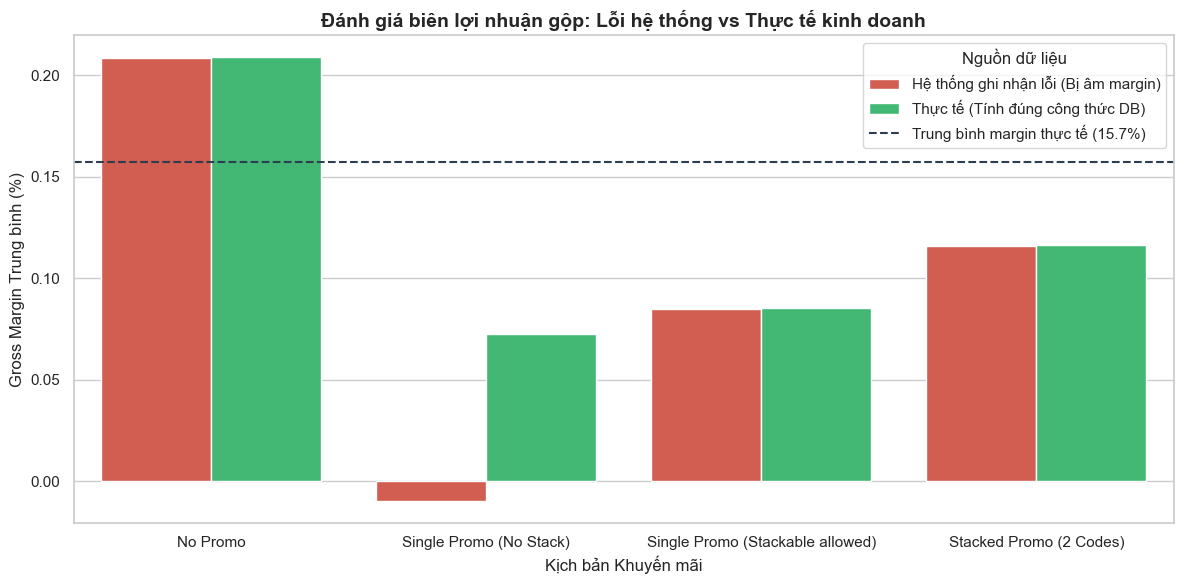

In [17]:
# Join dữ liệu mở rộng
df = order_items.merge(products[['product_id', 'price', 'cogs', 'category']], on='product_id', how='left')
df = df.merge(promotions[['promo_id', 'stackable_flag', 'promo_type', 'discount_value']], on='promo_id', how='left')
df['stackable_flag'] = df['stackable_flag'].fillna(-1) 
df['promo_scenario'] = df.apply(lambda x: categorize_promo(x['stackable_flag'], x['promo_id_2']), axis=1)

# Hàm tính toán lại doanh thu chuẩn xác
def calculate_correct_metrics(row):
    base_price = row['price'] 
    quantity = row['quantity']
    
    if pd.isna(row['promo_id']):
        correct_discount_amount = 0
    elif row['promo_type'] == 'percentage':
        correct_discount_amount = quantity * base_price * (row['discount_value'] / 100)
    elif row['promo_type'] == 'fixed':
        correct_discount_amount = quantity * row['discount_value']
    else:
        correct_discount_amount = row['discount_amount']
        
    total_revenue = (base_price * quantity) - correct_discount_amount
    net_unit_price = total_revenue / quantity if quantity > 0 else base_price
    return net_unit_price

df['net_unit_price_corrected'] = df.apply(calculate_correct_metrics, axis=1)
df['gross_margin_error'] = (df['unit_price'] - df['cogs']) / df['unit_price']
df['gross_margin_corrected'] = (df['net_unit_price_corrected'] - df['cogs']) / df['net_unit_price_corrected']

# Vẽ biểu đồ cột kép
plt.figure(figsize=(12, 6))
plot_data = df.melt(id_vars=['promo_scenario'], value_vars=['gross_margin_error', 'gross_margin_corrected'], var_name='Data_Source', value_name='Gross_Margin')
plot_data['Data_Source'] = plot_data['Data_Source'].replace({
    'gross_margin_error': 'Hệ thống ghi nhận lỗi (Bị âm margin)',
    'gross_margin_corrected': 'Thực tế (Tính đúng công thức DB)'
})

sns.barplot(data=plot_data, x='promo_scenario', y='Gross_Margin', hue='Data_Source', estimator=np.mean, errorbar=None, palette=['#e74c3c', '#2ecc71'])
plt.title('Đánh giá biên lợi nhuận gộp: Lỗi hệ thống vs Thực tế kinh doanh', fontsize=14, fontweight='bold')
plt.ylabel('Gross Margin Trung bình (%)')
plt.xlabel('Kịch bản Khuyến mãi')

avg_margin = df['gross_margin_corrected'].mean()
plt.axhline(y=avg_margin, color='#2c3e50', linestyle='--', label=f'Trung bình margin thực tế ({avg_margin:.1%})')
plt.legend(title='Nguồn dữ liệu')
plt.tight_layout()
plt.show()

# 3. Code vẽ Mini - Dashboard giải phẫu thất thoát do lỗi

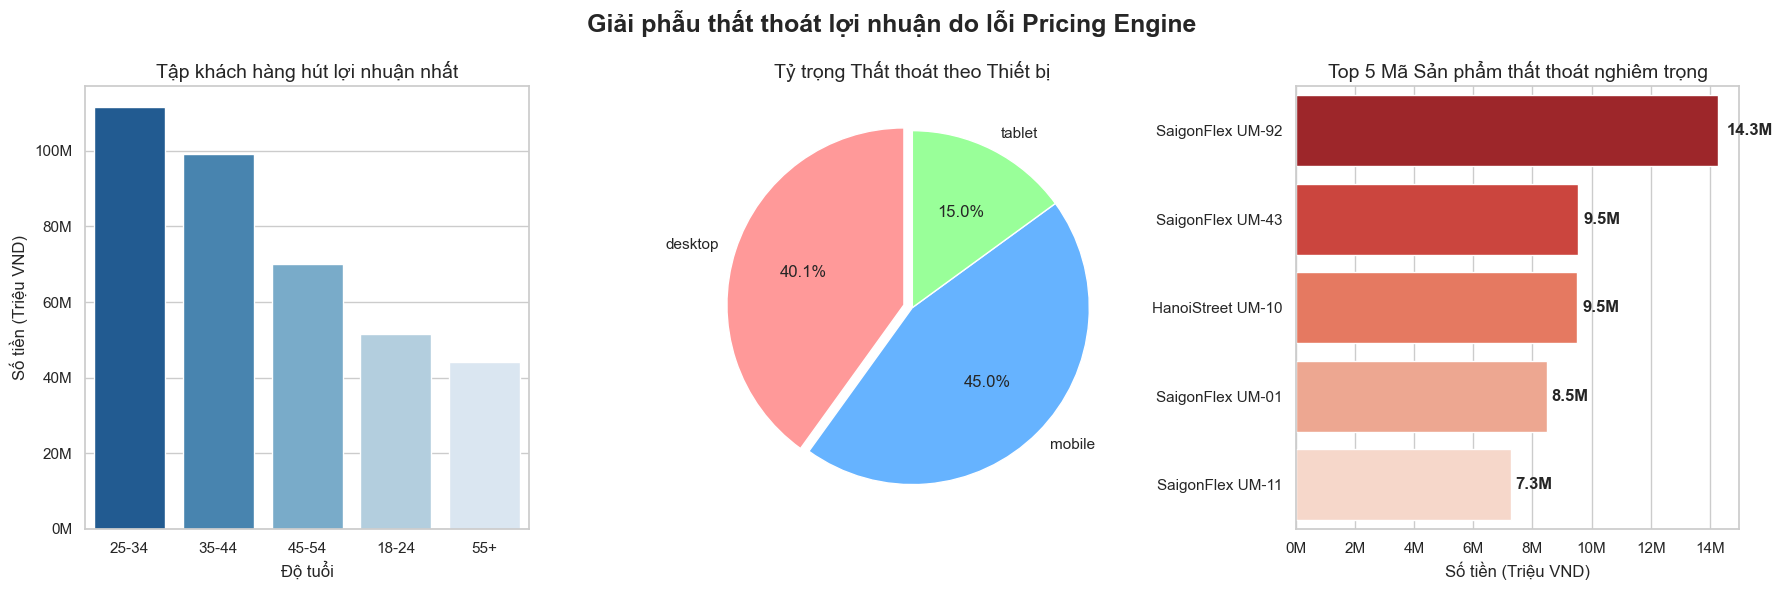

In [18]:
import matplotlib.ticker as ticker

# GHÉP NỐI (JOIN) MỞ RỘNG
df = order_items.merge(products[['product_id', 'product_name', 'price', 'cogs', 'category']], on='product_id', how='left')
df = df.merge(promotions[['promo_id', 'promo_type', 'discount_value', 'promo_channel']], on='promo_id', how='left')
df = df.merge(orders[['order_id', 'customer_id', 'device_type']], on='order_id', how='left')
df = df.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')

# TÍNH TOÁN LẠI TỪ ĐẦU (BYPASS LỖI UNIT_PRICE)
def calc_correct_net_revenue(row):
    base_price = row['price']
    quantity = row['quantity']
    if pd.isna(row['promo_id']):
        return base_price * quantity
    elif row['promo_type'] == 'percentage':
        return (base_price * quantity) - (quantity * base_price * (row['discount_value'] / 100))
    elif row['promo_type'] == 'fixed':
        return (base_price * quantity) - (quantity * row['discount_value'])
    else:
        return (base_price * quantity) - row['discount_amount']

# Tính thất thoát
df['corrected_revenue'] = df.apply(calc_correct_net_revenue, axis=1) # (Hàm bạn đã định nghĩa ở snippet 3)
df['error_revenue'] = (df['unit_price'] * df['quantity']) - df['discount_amount']
df['total_cogs'] = df['cogs'] * df['quantity']
df['profit_leakage'] = (df['corrected_revenue'] - df['total_cogs']) - (df['error_revenue'] - df['total_cogs'])

# Lọc nhóm mã bị lỗi fixed
bugged_df = df[df['promo_type'] == 'fixed'].copy()

age_impact = bugged_df.groupby('age_group')['profit_leakage'].sum().reset_index()
device_impact = bugged_df.groupby('device_type')['profit_leakage'].sum().reset_index()
top_products = bugged_df.groupby('product_name')['profit_leakage'].sum().nlargest(5).reset_index()

# Vẽ 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Giải phẫu thất thoát lợi nhuận do lỗi Pricing Engine', fontsize=18, fontweight='bold')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M')

# Plot 1
sns.barplot(ax=axes[0], data=age_impact.sort_values('profit_leakage', ascending=False), x='age_group', y='profit_leakage', hue='age_group', legend=False, palette='Blues_r')
axes[0].set_title('Tập khách hàng hút lợi nhuận nhất', fontsize=14)
axes[0].set_ylabel('Số tiền (Triệu VND)')
axes[0].set_xlabel('Độ tuổi')
axes[0].yaxis.set_major_formatter(formatter)

# Plot 2
axes[1].pie(device_impact['profit_leakage'], labels=device_impact['device_type'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'], explode=(0.05, 0, 0))
axes[1].set_title('Tỷ trọng Thất thoát theo Thiết bị', fontsize=14)

# Plot 3
sns.barplot(ax=axes[2], data=top_products, x='profit_leakage', y='product_name', hue='product_name', legend=False, palette='Reds_r')
axes[2].set_title('Top 5 Mã Sản phẩm thất thoát nghiêm trọng', fontsize=14)
axes[2].set_xlabel('Số tiền (Triệu VND)')
axes[2].set_ylabel('')
axes[2].xaxis.set_major_formatter(formatter)

for p in axes[2].patches:
    axes[2].text(p.get_width() + (p.get_width() * 0.02), p.get_y() + p.get_height() / 2, f"{p.get_width()*1e-6:.1f}M", ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Tỷ lệ quay lại

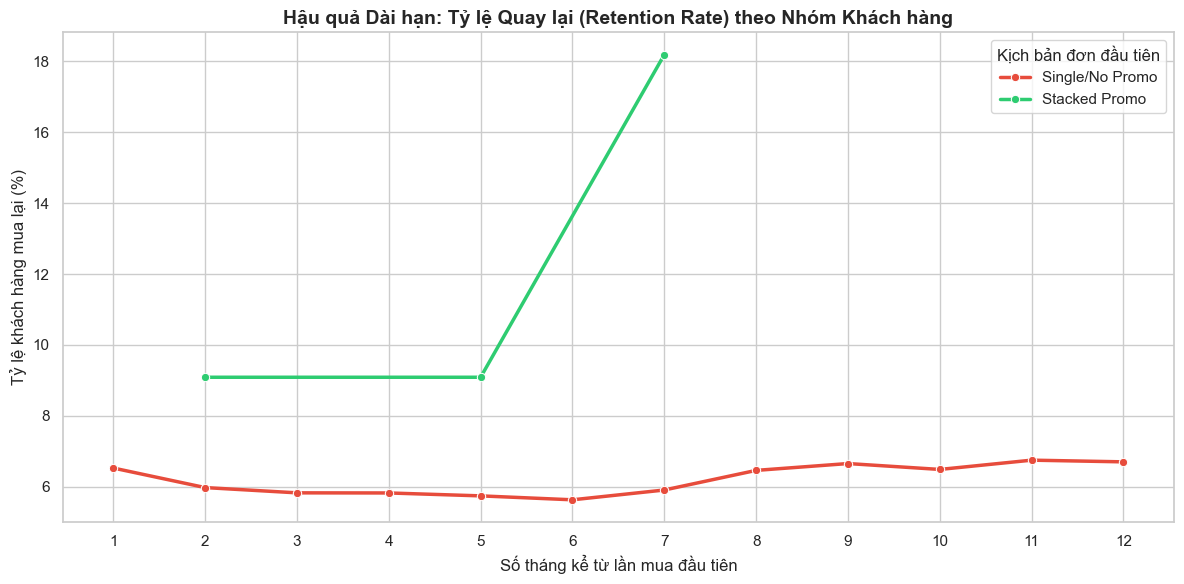

In [7]:
# 1. Xác định kịch bản khuyến mãi cho TỪNG ĐƠN HÀNG
order_promo = df_promo.groupby('order_id')['promo_scenario'].agg(
    lambda x: 'Stacked Promo' if 'Stacked Promo (2 Codes)' in x.values else 'Single/No Promo'
).reset_index()

# 2. Fix lỗi datetime trực tiếp trên bảng orders gốc
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

# 3. Merge để tạo df_orders_full
df_orders_full = orders.merge(order_promo, on='order_id', how='left')

# 4. Extract month (lúc này order_date đã chuẩn datetime nên .dt sẽ hoạt động mượt mà)
df_orders_full['order_month'] = df_orders_full['order_date'].dt.to_period('M')

# 5. Tìm Đơn hàng ĐẦU TIÊN của mỗi khách hàng
first_orders = df_orders_full.sort_values('order_date').groupby('customer_id').first().reset_index()
first_orders = first_orders[['customer_id', 'order_month', 'promo_scenario']]
first_orders.rename(columns={'order_month': 'cohort_month', 'promo_scenario': 'acquisition_channel_promo'}, inplace=True)

# 6. Gắn nhãn nhóm Cohort cho từng khách hàng vào bảng giao dịch
df_cohort = df_orders_full.merge(first_orders, on='customer_id', how='left')

# Tính toán số tháng kể từ tháng mua đầu tiên (Month Index)
df_cohort['month_index'] = (df_cohort['order_month'].dt.year - df_cohort['cohort_month'].dt.year) * 12 + \
                           (df_cohort['order_month'].dt.month - df_cohort['cohort_month'].dt.month)

# 7. Tính Tỷ lệ giữ chân (Retention Rate) theo Nhóm Khuyến mãi
# Lọc bỏ tháng 0 (Tháng mua lần đầu)
retention_data = df_cohort[df_cohort['month_index'] > 0]

# Đếm số lượng khách hàng unique quay lại mua trong từng tháng index, chia theo nhóm Promo
retention_counts = retention_data.groupby(['acquisition_channel_promo', 'month_index'])['customer_id'].nunique().reset_index()

# Đếm tổng số khách hàng ban đầu của mỗi nhóm
initial_customers = first_orders.groupby('acquisition_channel_promo')['customer_id'].nunique().reset_index(name='total_users')

# Merge và tính tỷ lệ %
retention_final = retention_counts.merge(initial_customers, on='acquisition_channel_promo')
retention_final['retention_rate'] = (retention_final['customer_id'] / retention_final['total_users']) * 100

# 8. Trực quan hóa: Line Chart so sánh Tỷ lệ giữ chân
plt.figure(figsize=(12, 6))
sns.lineplot(data=retention_final[retention_final['month_index'] <= 12], 
             x='month_index', y='retention_rate', hue='acquisition_channel_promo', 
             marker='o', linewidth=2.5, palette=['#e74c3c', '#2ecc71'])

plt.title('Hậu quả Dài hạn: Tỷ lệ Quay lại (Retention Rate) theo Nhóm Khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Số tháng kể từ lần mua đầu tiên')
plt.ylabel('Tỷ lệ khách hàng mua lại (%)')
plt.xticks(np.arange(1, 13, 1))
plt.legend(title='Kịch bản đơn đầu tiên')
plt.tight_layout()
plt.show()

## Phân tích Time-series và drll-down
Cell code này giúp trả lời lỗi này xảy ra khi nào ? Và hệ thống có đang cho phép áp mã giảm giá lớn hơn cả giá trị sản phẩm không?

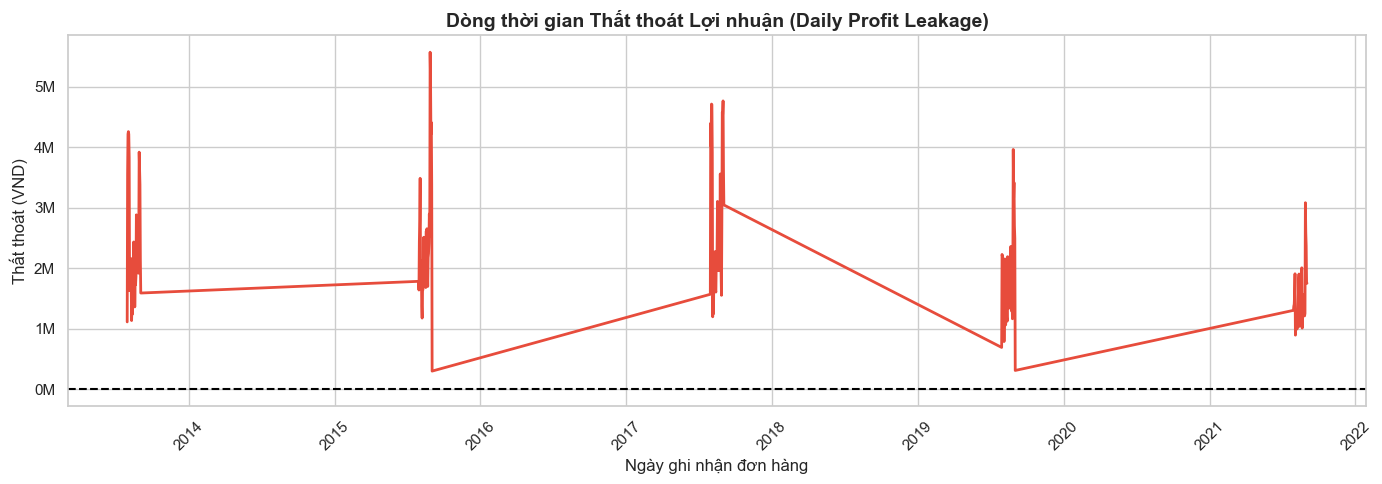

Số dòng sản phẩm bị áp mã giảm sâu hơn giá gốc: 0
Top 5 sản phẩm chịu lỗi nặng nhất (Giá gốc < Mức giảm):


,product_name,price,discount_value,profit_leakage


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- FIX LỖI: Bổ sung cột order_date bị thiếu ---
# Nếu bảng df chưa có cột 'order_date', ta sẽ kéo từ bảng orders sang
if 'order_date' not in df.columns:
    df = df.merge(orders[['order_id', 'order_date']], on='order_id', how='left')

# --- PHẦN 1.1: TIME-SERIES ANOMALY DETECTION ---
# Lấy ra các đơn hàng áp dụng mã Fixed
df_bugged = df[df['promo_type'] == 'fixed'].copy()

# Chuyển đổi định dạng thời gian
df_bugged['order_date'] = pd.to_datetime(df_bugged['order_date'], errors='coerce')

# Gom nhóm tổng thất thoát theo ngày
leakage_by_date = df_bugged.groupby(df_bugged['order_date'].dt.date)['profit_leakage'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=leakage_by_date, x='order_date', y='profit_leakage', color='#e74c3c', linewidth=2)
plt.title('Dòng thời gian Thất thoát Lợi nhuận (Daily Profit Leakage)', fontsize=14, fontweight='bold')
plt.xlabel('Ngày ghi nhận đơn hàng')
plt.ylabel('Thất thoát (VND)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PHẦN 1.2: DRILL-DOWN LUẬT KHUYẾN MÃI (MIN ORDER VALUE / PRICE BUG) ---
# So sánh Giá niêm yết của 1 sản phẩm vs Giá trị giảm cố định của mã
df_bugged['price_vs_discount_diff'] = df_bugged['price'] - df_bugged['discount_value']

# Lọc ra những case mà MÃ GIẢM GIÁ TRỪ NHIỀU HƠN CẢ GIÁ SẢN PHẨM (nguyên nhân gây âm doanh thu)
crazy_discount_cases = df_bugged[df_bugged['price_vs_discount_diff'] < 0]

print(f"Số dòng sản phẩm bị áp mã giảm sâu hơn giá gốc: {len(crazy_discount_cases)}")
print("Top 5 sản phẩm chịu lỗi nặng nhất (Giá gốc < Mức giảm):")
display(crazy_discount_cases[['product_name', 'price', 'discount_value', 'profit_leakage']].sort_values('profit_leakage', ascending=False).head())

## Phân tích Market Basket Analysic cho nhóm Stacked Promo 
Nhóm cộng dồn mã đang có lãi, nhưng rốt cuộc họ mua gì? Cùng xem họ có đang mua 1 món rẻ tiền ghép với 1 món đắt tiền để tận dụng bug không

In [13]:

from mlxtend.frequent_patterns import apriori, association_rules

# Lọc các đơn hàng có Kịch bản Stacked Promo
stacked_orders = df_promo[df_promo['promo_scenario'] == 'Stacked Promo (2 Codes)']

# Tạo ma trận giỏ hàng (Basket Matrix)
basket = (stacked_orders.groupby(['order_id', 'product_name'])['quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('order_id'))

# --- FIX WARNING: Đổi astype(int) thành astype(bool) ---
basket_binary = (basket > 0).astype(bool)

# --- TUNE THUẬT TOÁN: Hạ min_support xuống 1% (0.01) thay vì 5% ---
frequent_itemsets = apriori(basket_binary, min_support=0.01, use_colnames=True)

# Khai thác luật kết hợp (Association Rules)
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
    # Sắp xếp theo Lift (mức độ liên kết) và Confidence (độ tin cậy)
    rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])
    
    print("Top Combo Sản phẩm thường được mua cùng nhau khi Stack Promo (Min Support 1%):")
    display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
else:
    print("Vẫn không tìm thấy pattern nào. Hãy thử hạ min_support xuống 0.005 hoặc kiểm tra lại tệp dữ liệu!")

Top Combo Sản phẩm thường được mua cùng nhau khi Stack Promo (Min Support 1%):


,antecedents,consequents,support,confidence,lift


## Gom cụm (Clustering) Tệp khách hàng nghi ngờ trục lợi

Các nhóm tuổi trong data: ['35-44' '18-24' '45-54' '25-34' '55+']
Các loại thiết bị trong data: ['desktop' 'mobile' 'tablet']


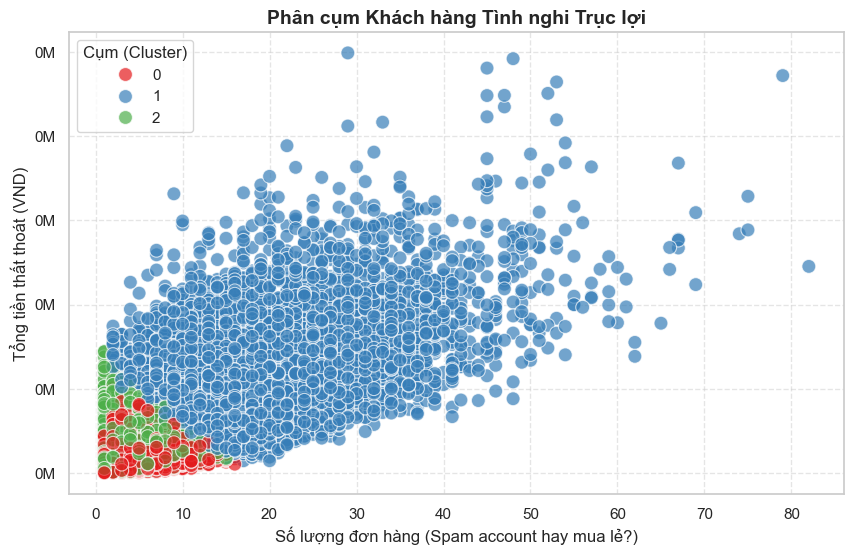

Phân tích chân dung các cụm tình nghi:


,customer_id,total_leakage,total_orders,avg_quantity_per_order
fraud_cluster,,,,
0,75588.993666,6128.422833,3.452989,3.257718
1,88277.987669,49922.735989,16.359342,4.569116
2,76089.328878,9172.505650,3.289485,5.830748


In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker

# 1. In ra các giá trị thực tế trong data để kiểm tra format text
print("Các nhóm tuổi trong data:", df['age_group'].unique())
print("Các loại thiết bị trong data:", df['device_type'].unique())

# 2. Lọc tệp khách hàng gây thất thoát (profit_leakage > 0)
# (Bạn có thể thêm lại điều kiện tuổi/thiết bị sau khi xem log in ra ở trên)
suspects_df = df[df['profit_leakage'] > 0].copy()

# Feature Engineering: Tổng hợp dữ liệu theo TỪNG KHÁCH HÀNG
customer_features = suspects_df.groupby('customer_id').agg(
    total_leakage=('profit_leakage', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_quantity_per_order=('quantity', 'mean')
).reset_index()

# 3. CHỐT CHẶN AN TOÀN (Safety Check)
if len(customer_features) == 0:
    print("⚠️ Tệp dữ liệu rỗng! Không có khách hàng nào thỏa mãn điều kiện lọc.")
elif len(customer_features) < 3:
    print(f"⚠️ Chỉ có {len(customer_features)} khách hàng. Dữ liệu quá ít để chạy K-Means (cần ít nhất 3).")
else:
    # Chuẩn hóa dữ liệu (Standardization)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(customer_features[['total_leakage', 'total_orders', 'avg_quantity_per_order']])

    # Chạy thuật toán K-Means Clustering (Chia làm 3 cụm)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    customer_features['fraud_cluster'] = kmeans.fit_predict(features_scaled)

    # Trực quan hóa kết quả phân cụm bằng Scatter Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=customer_features, x='total_orders', y='total_leakage', 
                    hue='fraud_cluster', palette='Set1', s=100, alpha=0.7)

    plt.title('Phân cụm Khách hàng Tình nghi Trục lợi', fontsize=14, fontweight='bold')
    plt.xlabel('Số lượng đơn hàng (Spam account hay mua lẻ?)')
    plt.ylabel('Tổng tiền thất thoát (VND)')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
    plt.legend(title='Cụm (Cluster)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # In ra phân tích chân dung các cụm
    cluster_summary = customer_features.groupby('fraud_cluster').mean()
    print("Phân tích chân dung các cụm tình nghi:")
    display(cluster_summary)